In [4]:
import os,sys
import math
import numpy as np
import pandas as pd
import dask.dataframe as dd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import confusion_matrix, cohen_kappa_score, roc_curve, auc


In [5]:
df = dd.read_parquet('/root/data/rrr/integrated_weather_dataset/data/integrated/parquet_fixed/2006.parquet')
pdf = df.compute()
pdf

,Timestamp,Site,Latitude,Longitude,ZWD,Wet Gradient North,Wet Gradient East,IVT,Rutz_Label_exact,IVT_approx,Rutz_Label_approx,Guan_Label_exact,Guan_Label_approx,Precipitation_Label_exact,Precipitation_Label_approx,ffw
0,2006-01-01 00:00:00.000000,7ODM,34.116407,-117.093192,98.8,-0.83,-1.14,486.503723,1.0,486.503723,1.0,0.0,0.0,0.0,0.0,0
1,2006-01-01 00:05:00.000000,7ODM,34.116407,-117.093192,97.9,-0.83,-1.15,NaN,NaN,486.503723,1.0,NaN,0.0,NaN,0.0,0
2,2006-01-01 00:10:00.000000,7ODM,34.116407,-117.093192,97.0,-0.83,-1.16,NaN,NaN,486.503723,1.0,NaN,0.0,NaN,0.0,0
3,2006-01-01 00:15:00.000000,7ODM,34.116407,-117.093192,96.1,-0.82,-1.16,NaN,NaN,486.503723,1.0,NaN,0.0,NaN,0.0,0
4,2006-01-01 00:20:00.000000,7ODM,34.116407,-117.093192,95.2,-0.82,-1.17,NaN,NaN,486.503723,1.0,NaN,0.0,NaN,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37013258,2006-12-31 23:35:00.000000,WWMT,33.955313,-116.653855,37.2,0.14,-0.05,NaN,NaN,NaN,0.0,NaN,1.0,NaN,0.0,0
37013259,2006-12-31 23:40:00.000000,WWMT,33.955313,-116.653855,36.9,0.14,-0.07,NaN,NaN,NaN,0.0,NaN,1.0,NaN,0.0,0
37013260,2006-12-31 23:45:00.000000,WWMT,33.955313,-116.653855,36.6,0.14,-0.08,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0
37013261,2006-12-31 23:50:00.000000,WWMT,33.955313,-116.653855,36.2,0.13,-0.10,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0



Basic Statistics:
Total Timestamps: 37013263
Events detected by both methods: 11799 (0.0%)
Events detected by neither method: 33708446 (91.1%)
Events detected only by Guan: 2769647 (7.5%)
Events detected only by Rutz: 523371 (1.4%)

Metrics:
Accuracy: 0.911
Precision: 0.022
Recall: 0.004
Specificity: 0.985
F1 Score: 0.007

Cohen's Kappa: -0.018


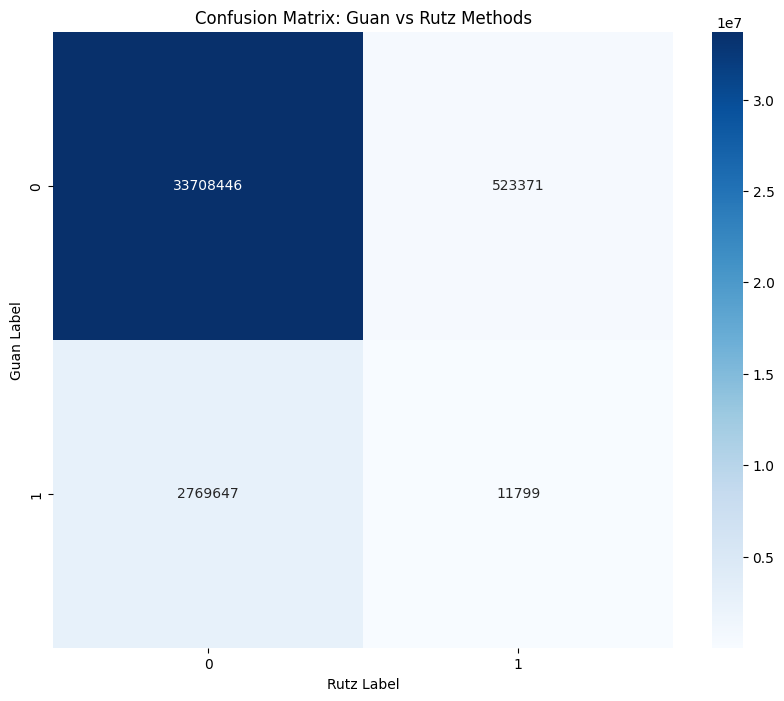

In [6]:

total_events = len(pdf)
both_detected = sum((pdf['Guan_Label_approx'] == 1) & (pdf['Rutz_Label_approx'] == 1))
neither_detected = sum((pdf['Guan_Label_approx'] == 0) & (pdf['Rutz_Label_approx'] == 0))
only_guan = sum((pdf['Guan_Label_approx'] == 1) & (pdf['Rutz_Label_approx'] == 0))
only_rutz = sum((pdf['Guan_Label_approx'] == 0) & (pdf['Rutz_Label_approx'] == 1))

# Print basic statistics
print("\nBasic Statistics:")
print(f"Total Timestamps: {total_events}")
print(f"Events detected by both methods: {both_detected} ({both_detected/total_events*100:.1f}%)")
print(f"Events detected by neither method: {neither_detected} ({neither_detected/total_events*100:.1f}%)")
print(f"Events detected only by Guan: {only_guan} ({only_guan/total_events*100:.1f}%)")
print(f"Events detected only by Rutz: {only_rutz} ({only_rutz/total_events*100:.1f}%)")

# Confusion matrix and metrics
cm = confusion_matrix(pdf['Guan_Label_approx'], pdf['Rutz_Label_approx'])
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

print("\nMetrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")

kappa = cohen_kappa_score(pdf['Guan_Label_approx'], pdf['Rutz_Label_approx'])
print(f"\nCohen's Kappa: {kappa:.3f}")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Guan vs Rutz Methods')
plt.ylabel('Guan Label')
plt.xlabel('Rutz Label')
plt.show()


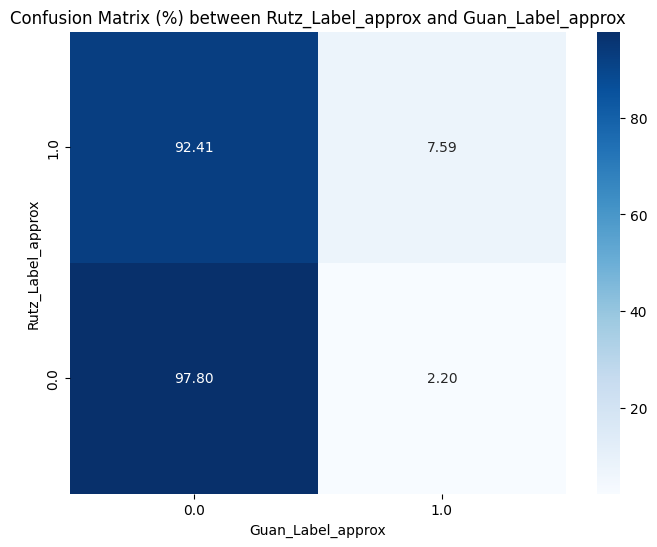

In [7]:
cm = confusion_matrix(df['Rutz_Label_approx'], df['Guan_Label_approx'])

cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap='Blues', cbar=True, 
            xticklabels=df['Guan_Label_approx'].unique(), 
            yticklabels=df['Rutz_Label_approx'].unique())
plt.title("Confusion Matrix (%) between Rutz_Label_approx and Guan_Label_approx")
plt.xlabel('Guan_Label_approx')
plt.ylabel('Rutz_Label_approx')
plt.show()


In [8]:
crosstab = pd.crosstab(pdf['Rutz_Label_approx'], pdf['Guan_Label_approx'])
print(crosstab)


Guan_Label_approx       0.0      1.0
Rutz_Label_approx                   
0.0                33708446  2769647
1.0                  523371    11799


In [9]:
TP = crosstab.loc[1.0, 1.0]
TN = crosstab.loc[0.0, 0.0]
FP = crosstab.loc[0.0, 1.0]
FN = crosstab.loc[1.0, 0.0]
accuracy = (TP + TN) / crosstab.sum().sum()
precision_1 = TP / (TP + FP) if (TP + FP) != 0 else 0
recall_1 = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) != 0 else 0
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision for Guan_Label_approx: {precision_1:.4f}")
print(f"Recall for Guan_Label_approx: {recall_1:.4f}")
print(f"F1 Score for Guan_Label_approx: {f1_score_1:.4f}")


Accuracy: 0.9110
Precision for Guan_Label_approx: 0.0042
Recall for Guan_Label_approx: 0.0220
F1 Score for Guan_Label_approx: 0.0071
